In [4]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import time
from langgraph.checkpoint.memory import InMemorySaver  # persistent storage in ram , use for demo testing 

load_dotenv()

True

In [2]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str


In [5]:
def step1(state: CrashState):
    print("Step 1 done")
    return {"step1":"done","input":state['input']}

def step2(sate: CrashState):
    print("step 2 started")
    time.sleep(30)
    return {"step2":"done"}

def step3(state:CrashState):
    print("step 3 started")
    return {"step3":"done"}

In [6]:
graph = StateGraph(CrashState)


graph.add_node("step1",step1)
graph.add_node("step2",step2)
graph.add_node("step3",step3)

graph.add_edge(START,"step1")
graph.add_edge("step1","step2")
graph.add_edge("step2","step3")
graph.add_edge("step3",END)

saver = InMemorySaver()

build= graph.compile(checkpointer=saver)

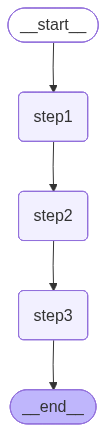

In [7]:
build

In [10]:
input_data = {"input":"start"}
build.invoke(input_data,config={'configurable':{'thread_id':'thread_1'}})

Step 1 done
step 2 started


KeyboardInterrupt: 

In [11]:
build.get_state({'configurable':{'thread_id':'thread_1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f100bfa-5da2-66d9-8001-e213044643a5'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-02-03T05:17:34.648700+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f100bfa-5d9e-6011-8000-40c7d54ab111'}}, tasks=(PregelTask(id='7af17ab5-9338-48e7-7f6d-8801b41ffba3', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [14]:
list(build.get_state_history({'configurable':{'thread_id':'thread_1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f100bfa-5da2-66d9-8001-e213044643a5'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-02-03T05:17:34.648700+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f100bfa-5d9e-6011-8000-40c7d54ab111'}}, tasks=(PregelTask(id='7af17ab5-9338-48e7-7f6d-8801b41ffba3', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f100bfa-5d9e-6011-8000-40c7d54ab111'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-02-03T05:17:34.646888+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkp

In [15]:
# re run to show fault tolerance
final_state = build.invoke(None,config={'configurable':{'thread_id':'thread_1'}})
print(final_state)

step 2 started
step 3 started
{'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}
